**Importing Necessary Libraries**

---



In [7]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# !pip install -q datasets transformers tabpfn scikit-learn

**Loading Necessary Datasets from Hugging Face**

---



In [9]:
from google.colab import files
import zipfile
uploaded = files.upload()

zip_path = "Mergence.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content/Mergence")

# Fraud detection data
cc_fraud_ds = load_dataset("David-Egea/Creditcard-fraud-detection")
fraud_df = cc_fraud_ds['train'].to_pandas()
fraud_df.to_csv('Mergence/Mergence/Data/creditcard.csv', index=False)

# Customer churn data
churn_train_dataset = load_dataset("aai510-group1/telco-customer-churn", split="train")
churn_val_dataset = load_dataset("aai510-group1/telco-customer-churn", split="validation")
churn_test_dataset = load_dataset("aai510-group1/telco-customer-churn", split="test")

churn_train_df = churn_train_dataset.to_pandas()
churn_val_df = churn_val_dataset.to_pandas()
churn_test_df = churn_test_dataset.to_pandas()


Saving Mergence.zip to Mergence (1).zip


**Telco Customer Churn Information**

---



In [10]:

# churn_train_df = pd.read_csv('Mergence/Mergence/Data/telco_churn.csv')
churn_train_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4225 entries, 0 to 4224
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                4225 non-null   int64  
 1   Avg Monthly GB Download            4225 non-null   int64  
 2   Avg Monthly Long Distance Charges  4225 non-null   float64
 3   Churn                              4225 non-null   int64  
 4   Churn Category                     1121 non-null   object 
 5   Churn Reason                       1121 non-null   object 
 6   Churn Score                        4225 non-null   int64  
 7   City                               4225 non-null   object 
 8   CLTV                               4225 non-null   int64  
 9   Contract                           4225 non-null   object 
 10  Country                            4225 non-null   object 
 11  Customer ID                        4225 non-null   objec

In [11]:
#Statistics of customer churn dataset
churn_train_df.describe()

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Score,CLTV,Dependents,Device Protection Plan,Internet Service,Latitude,...,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data
count,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,...,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000
mean,46.451124,20.740828,22.766963,0.265325,58.281183,4409.751243,0.233136,0.346982,0.790296,36.207274,...,0.349586,0.383669,32.681893,2306.078107,6.965680,754.719141,1.953846,3065.809082,0.200000,0.677870
std,16.731518,20.366105,15.429992,0.441559,21.197931,1170.599119,0.422878,0.476066,0.407146,2.471090,...,0.476896,0.486336,24.621041,2271.448881,25.250169,854.909725,7.814374,2884.817379,0.400047,0.467348
min,19.000000,0.000000,0.000000,0.000000,5.000000,2003.000000,0.000000,0.000000,0.000000,32.555828,...,0.000000,0.000000,1.000000,18.800000,0.000000,0.000000,0.000000,21.360000,0.000000,0.000000
25%,32.000000,4.000000,9.050000,0.000000,40.000000,3493.000000,0.000000,0.000000,1.000000,33.994524,...,0.000000,0.000000,9.000000,401.500000,0.000000,67.680000,0.000000,592.750000,0.000000,0.000000
50%,46.000000,17.000000,22.570000,0.000000,61.000000,4531.000000,0.000000,0.000000,1.000000,36.205465,...,0.000000,0.000000,30.000000,1424.600000,0.000000,396.640000,0.000000,2151.470000,0.000000,1.000000
75%,60.000000,27.000000,36.170000,1.000000,75.000000,5381.000000,0.000000,1.000000,1.000000,38.196497,...,1.000000,1.000000,56.000000,3846.750000,0.000000,1200.000000,0.000000,4845.750000,0.000000,1.000000
max,80.000000,85.000000,49.990000,1.000000,96.000000,6500.000000,1.000000,1.000000,1.000000,41.962127,...,1.000000,1.000000,72.000000,8672.450000,150.000000,3564.000000,49.790000,11979.340000,1.000000,1.000000


**Credit Card Dataset Information**

---



In [12]:
fraud_df = pd.read_csv('Mergence/Mergence/Data/creditcard.csv')
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [13]:
#Statistics of credit card fraud dataset
fraud_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



**Exploratory Data Analysis (EDA)**

---


Credit Card Fraud Dataset Exploration:


In [14]:
print('Null count:')
fraud_df.isnull().sum()

Null count:


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [15]:
#Fraud count of credit card fraud dataset
fraud_counts = fraud_df['Class'].value_counts()
print(fraud_counts)

print("Target Distribution of the dataset")
target_dist = fraud_df['Class'].value_counts(normalize = True) * 100

print(f'\n{target_dist}')

Class
0    284315
1       492
Name: count, dtype: int64
Target Distribution of the dataset

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


<Axes: xlabel='Class'>

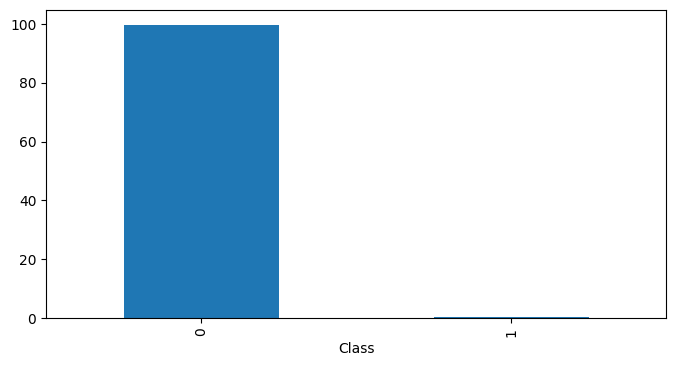

In [16]:
target_dist.plot(kind='bar', figsize=(8,4))

From the above distribution its clear that most credit card transactions are not fraud cases, the percentage being 99.8% for transactions that aren't fraud and 0.2% for fraudulent transactions. In conclusion this would make this an unbalanced dataset.

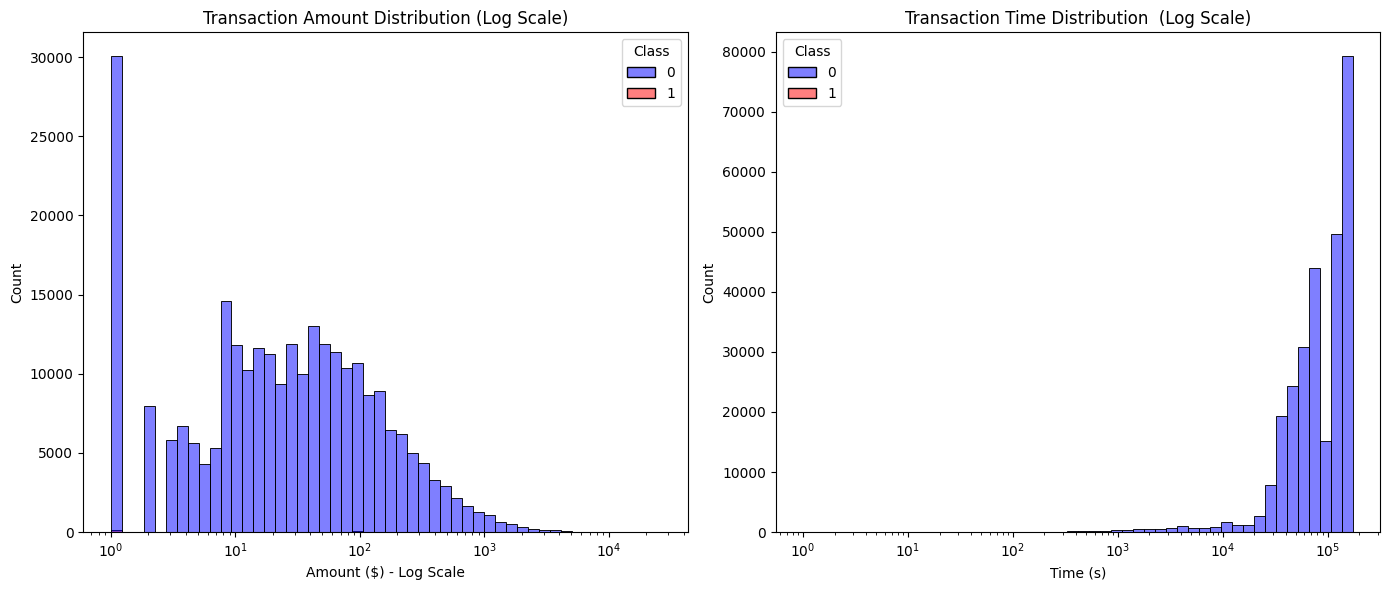

In [17]:
fraud_df['Amount'] = fraud_df['Amount'].fillna(0).astype(int)
fraud_df['Time'] = fraud_df['Time'].fillna(0).astype(int)

plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
sns.histplot(data = fraud_df, x='Amount', hue='Class', bins= 50, kde=False,
             log_scale=True, palette=['blue', 'red'])
plt.xlabel('Amount ($) - Log Scale')
plt.title('Transaction Amount Distribution (Log Scale)')

plt.subplot(1,2,2)
sns.histplot(data = fraud_df, x= 'Time', hue='Class', bins = 50, kde= False,
             log_scale= True, palette=['blue','red'], common_norm = False)
plt.xlabel('Time (s)')
plt.title('Transaction Time Distribution  (Log Scale)')

plt.tight_layout()
plt.show()

Amount Distribution PLot Analysis:

The amount distribution plot displays that there is a high number of transactions with low monetary value and less number of transactions with high monetary value, making the data right skewed as shown above. It is also clear that there is almost no cases of fraud transactions.




Time Distribution PLot Analysis:

The time distribution plot shows that there are less transactions with low time frames and a large number of transactions which occur in highly dense time frames, which makes this data left skewed. This plot also shows thats are almost no fraud transaction cases within these time frames.

Telco Customer Churn Dataset Exploration:


In [18]:
#Null count of each column in the customer churn dataset
print('Null count')
churn_train_df.isna().sum()

Null count


,0
Age,0
Avg Monthly GB Download,0
Avg Monthly Long Distance Charges,0
Churn,0
Churn Category,3104
Churn Reason,3104
Churn Score,0
City,0
CLTV,0
Contract,0


In [19]:
#Seperating object types and numberical types from the dataset
churn_train_df.dtypes

#Setting 'Unknown' values in this column as No internet for later analysis below
churn_train_df["Internet Type"].fillna('No Internet')
churn_obj_df =  churn_train_df.select_dtypes(include=['object'])
churn_num_df = churn_train_df.select_dtypes(exclude=['object'])

print('Churn count')
churn_count = churn_train_df['Churn'].value_counts()
print(churn_count)

print('Target distribution of the Dataset')
churn_target_dist = churn_train_df['Churn'].value_counts(normalize = True) * 100
print(f'\n{churn_target_dist}')

Churn count
Churn
0    3104
1    1121
Name: count, dtype: int64
Target distribution of the Dataset

Churn
0    73.467456
1    26.532544
Name: proportion, dtype: float64


<Axes: xlabel='Churn'>

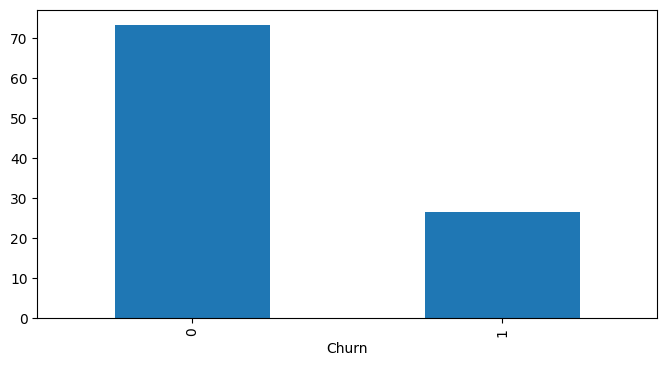

In [20]:
churn_target_dist.plot(kind = 'bar', figsize = (8, 4))

From the above stats and bar graph its clear that there is a 73.5% customer retention and a 26.5 customer churn rate making this an unbalanced dataset.

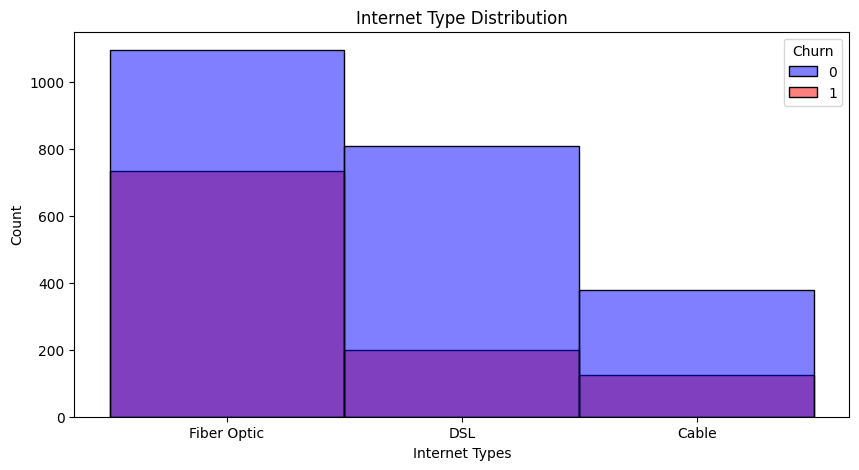

In [21]:
churn_num_df = churn_num_df.fillna(0).astype(int)

plt.figure(figsize=(10,5))
sns.histplot(data= churn_train_df, x='Internet Type', hue='Churn',
             palette=['blue','red'])
plt.xlabel('Internet Types')
plt.title('Internet Type Distribution')
plt.show()
# Internet Type
# Monthly Charge
# Contract

From this historgam it is clear that most users that are retained and churned use fiber optics as their internet service type, where as the most users retained with a less churn rate are users who use DSL service as an Internet type.

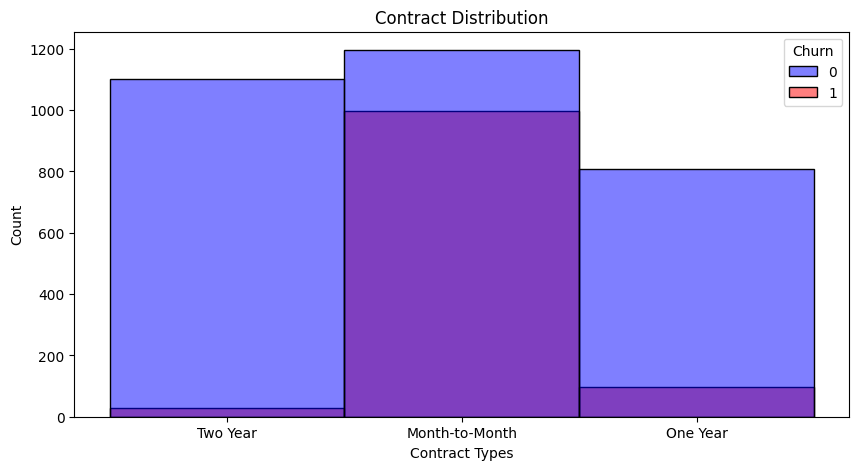

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(data=churn_train_df, x='Contract', hue='Churn', palette=['blue', 'red'])
plt.xlabel('Contract Types')
plt.title('Contract Distribution')
plt.show()

From the above plot its clear that the highest churn rate of users come from the users who renew their contracts every month compared to users who renew every year.

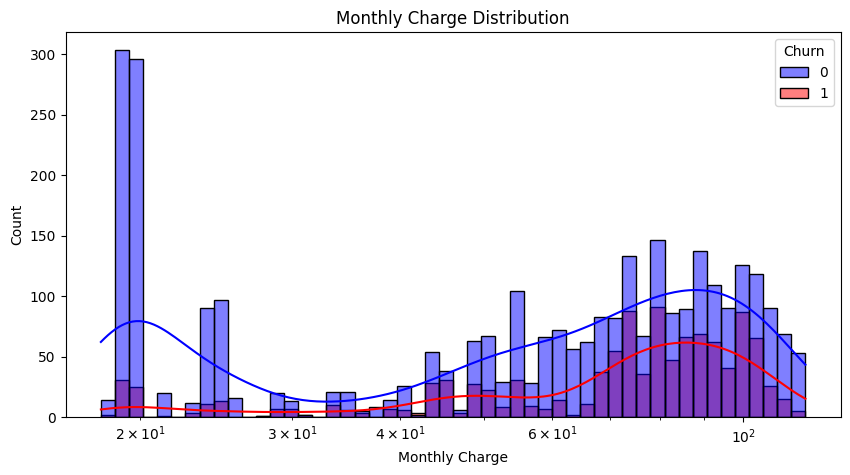

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(data=churn_num_df, x="Monthly Charge", hue='Churn', bins=50, kde=True,
             log_scale= True, palette=['blue', 'red'])

plt.xlabel('Monthly Charge')
plt.title('Monthly Charge Distribution')
plt.show()

From the above histogram it is clear that users that pay a high sum for monthly charges tend to add to the churn rate where as users who pay only a little sum tend to stay with their services

**Fraud Data Pre-processing**

---



Credit card fraud data cleaning and scaling:

In [24]:
from sklearn.preprocessing import StandardScaler

fraud_clean = fraud_df.copy()

#Handling infinite values
fraud_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

#Filling null values with the column median
fraud_clean = fraud_clean.fillna(fraud_clean.median(numeric_only=True))

fraud_clean.duplicated().sum()
fraud_clean = fraud_clean.drop_duplicates()

#Dropping exact row duplicates to reduce redundancy and clean the data
fraud_clean.duplicated().sum()

#Dropping time column since its not predictive
fraud_clean = fraud_clean.drop(columns=['Time'])

print(f"Clean Shape: {fraud_clean.shape}")

#Initializing scaler
scaler_fraud = StandardScaler()

#scaling amount feature for better results
fraud_clean['Amount'] = scaler_fraud.fit_transform(fraud_clean[['Amount']])
print(f"Amount mean: {fraud_clean['Amount'].mean():.6f}")
print(f"Amount std: {fraud_clean['Amount'].std():.6f}")

Clean Shape: (283726, 30)
Amount mean: -0.000000
Amount std: 1.000002


Train/Val split and save:

In [25]:
from sklearn.model_selection import train_test_split
import os

X = fraud_clean.drop('Class', axis=1)
y = fraud_clean['Class']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Saving train/val splits to csv
os.makedirs('./data', exist_ok=True)
X_train.to_csv('./data/fraud_train.csv', index=False)
X_val.to_csv('./data/fraud_val.csv', index=False)
y_train.to_csv('./data/fraud_train_labels.csv', index=False)
y_val.to_csv('./data/fraud_val_labels.csv', index=False)
fraud_clean.to_csv('./data/fraud_preprocessed.csv', index=False)

**Churn Data Pre-processing**

---



Telco churn data cleaning:

In [26]:
train = churn_train_df.copy()
val   = churn_val_df.copy()
test  = churn_test_df.copy()

#Dropping columns that might cause data leakage
leak_columns = [
    'Customer ID',
    'Churn Category',
    'Churn Reason',
    'Churn Score',
    'Customer Status',
    'Lat Long',
    'Country',
    'State',
    'Quarter'
]

for df in [train, val, test]:
    df.drop(columns=[c for c in leak_columns if c in df.columns], inplace=True, errors='ignore')


#Seperating numerical and categorical values
train_num = train.select_dtypes(exclude=['object']).copy()
train_cat = train.select_dtypes(include=['object']).copy()


#Handling numeric null values with median
num_medians = train_num.median()
for df in [train, val, test]:
    df[num_medians.index] = df[num_medians.index].fillna(num_medians)
  # print(churn_num_clean[col])


#Handling object null values with the most common value
cat_modes = train_cat.mode().iloc[0]
for df in [train, val, test]:
    for col, mode_val in cat_modes.items():
        if col in df.columns:
            df[col] = df[col].fillna(mode_val)
  # print(churn_obj_clean[col])

Telco customer churn Encoding Categorical data for Model Training adn scaling:

In [27]:
#Seperating categorical columns from numeric to encode
categorical_columns = train.select_dtypes(include=['object']).columns.tolist()
train_dummies = pd.get_dummies(train[categorical_columns], drop_first=True)
val_dummies = pd.get_dummies(val[categorical_columns], drop_first=True)
test_dummies = pd.get_dummies(test[categorical_columns], drop_first=True)

#adding missing dummy columns with 0
train_cols = train_dummies.columns
val_dummies = val_dummies.reindex(columns=train_cols, fill_value=0)
test_dummies = test_dummies.reindex(columns=train_cols, fill_value=0)

numeric_cols_raw = train.drop(columns=categorical_columns).columns
train_num = train[numeric_cols_raw]
val_num   = val[numeric_cols_raw]
test_num  = test[numeric_cols_raw]

#Rebuilding encoded dataframes
train_encoded = pd.concat([train_num, train_dummies], axis=1)
val_encoded   = pd.concat([val_num,   val_dummies],   axis=1)
test_encoded  = pd.concat([test_num,  test_dummies],  axis=1)

# train_encoded.head(20)

#Scaling Numeric columns in the encoded data except the target column
num_cols = train_encoded.select_dtypes(include=['int64', 'float64', 'float32']).columns.tolist()
if 'Churn' in num_cols:
    num_cols.remove('Churn')

#Initializing scaler
scaler_churn = StandardScaler()
train_encoded[num_cols] = scaler_churn.fit_transform(train_encoded[num_cols])
val_encoded[num_cols]   = scaler_churn.transform(val_encoded[num_cols])
test_encoded[num_cols]  = scaler_churn.transform(test_encoded[num_cols])


Train/Val split and save:


In [28]:
X_train_churn = train_encoded.drop('Churn', axis=1)
y_train_churn = train_encoded['Churn']

X_val_churn = val_encoded.drop('Churn', axis=1)
y_val_churn = val_encoded['Churn']

X_test_churn = test_encoded.drop('Churn', axis=1)
y_test_churn = test_encoded['Churn']

# Save
X_train_churn.to_csv('./data/churn_train.csv', index=False)
y_train_churn.to_csv('./data/churn_train_labels.csv', index=False)

X_val_churn.to_csv('./data/churn_val.csv', index=False)
y_val_churn.to_csv('./data/churn_val_labels.csv', index=False)

X_test_churn.to_csv('./data/churn_test.csv', index=False)
y_test_churn.to_csv('./data/churn_test_labels.csv', index=False)


In [29]:
#For Trainer in merge and evaluate script
train_encoded = X_train_churn.copy()
train_encoded['Churn'] = y_train_churn

val_encoded = X_val_churn.copy()
val_encoded['Churn'] = y_val_churn

test_encoded = X_test_churn.copy()
test_encoded['Churn'] = y_test_churn

train_encoded.to_csv('./data/churn_train_with_churn_col.csv', index=False)
val_encoded.to_csv('./data/churn_val_with_churn_col.csv', index=False)
test_encoded.to_csv('./data/churn_test_with_churn_col.csv', index=False)